# CUSTOMER SEGMENTATION ANALYSIS

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
print("librarirs are imported succesfully")

librarirs are imported succesfully


In [ ]:
df = pd.read_csv("ifood_df.csv")
df.head(10)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
5,62513.0,0,1,16,520,42,98,0,42,14,...,1,0,0,0,0,1,0,702,688,0
6,55635.0,0,1,34,235,65,164,50,49,27,...,0,0,0,0,1,0,0,563,536,0
7,33454.0,1,0,32,76,10,56,3,1,23,...,0,0,0,0,0,0,1,146,123,0
8,30351.0,1,0,19,14,0,24,3,3,2,...,1,0,0,0,0,0,1,44,42,0
9,5648.0,1,1,68,28,0,6,1,1,13,...,1,0,0,0,0,0,1,36,23,1


In [ ]:
df.shape

(2205, 39)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [ ]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [ ]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [ ]:
df.duplicated().sum()

np.int64(184)

In [ ]:
df.drop(
    columns=['Z_CostContact','Z_Revenue'],
    inplace=True
)

In [ ]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Days',
       'marital_Divorced', 'marital_Married', 'marital_Single',
       'marital_Together', 'marital_Widow', 'education_2n Cycle',
       'education_Basic', 'education_Graduation', 'education_Master',
       'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall'],
      dtype='object')

In [ ]:
for col in df.columns:
    print(col)

Income
Kidhome
Teenhome
Recency
MntWines
MntFruits
MntMeatProducts
MntFishProducts
MntSweetProducts
MntGoldProds
NumDealsPurchases
NumWebPurchases
NumCatalogPurchases
NumStorePurchases
NumWebVisitsMonth
AcceptedCmp3
AcceptedCmp4
AcceptedCmp5
AcceptedCmp1
AcceptedCmp2
Complain
Response
Age
Customer_Days
marital_Divorced
marital_Married
marital_Single
marital_Together
marital_Widow
education_2n Cycle
education_Basic
education_Graduation
education_Master
education_PhD
MntTotal
MntRegularProds
AcceptedCmpOverall


In [ ]:
df.nunique()

,0
Income,1963
Kidhome,3
Teenhome,3
Recency,100
MntWines,775
MntFruits,158
MntMeatProducts,551
MntFishProducts,182
MntSweetProducts,176
MntGoldProds,212


# Box plot for the total amount spent on all products (MntTotal)

Our analysis will be focused on total amount spent on all products (MntTotal). Boxplot will help us to find outliers if any.

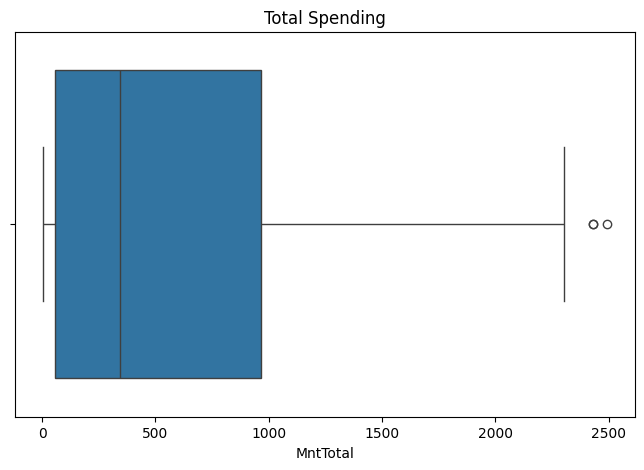

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["MntTotal"]
)

plt.title("Total Spending")
plt.show()

In [ ]:
#Mnt total outlier check
Q1 = df["MntTotal"].quantile(0.25)
Q3 = df["MntTotal"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-1306.0
2326.0


In [ ]:
df = df[
    (df["MntTotal"] >= lower)
    &
    (df["MntTotal"] <= upper)
]

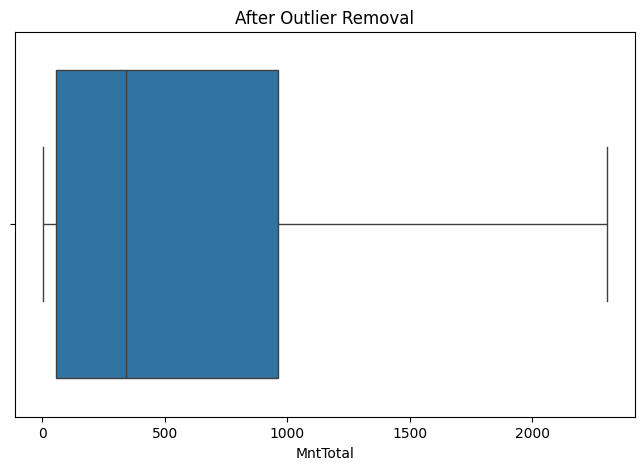

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["MntTotal"])
plt.title("After Outlier Removal")
plt.show()

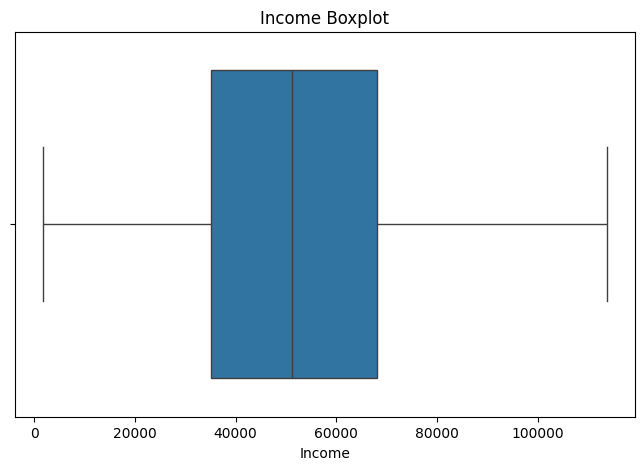

In [ ]:
#income boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Income"])
plt.title("Income Boxplot")
plt.show()

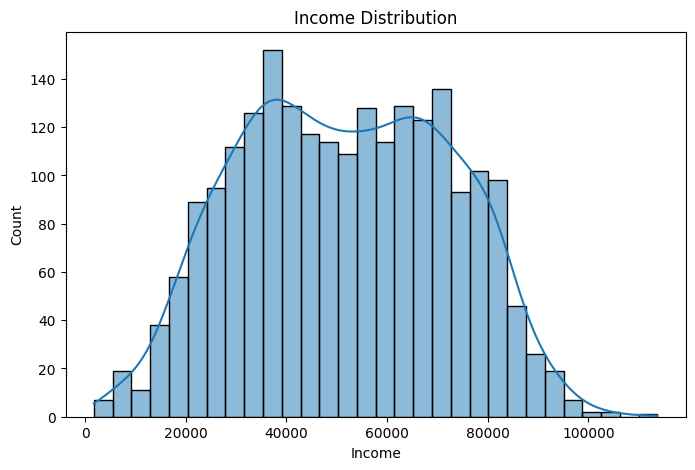

In [ ]:
#histplot for income distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Income"],
    bins=30,
    kde=True
)

plt.title("Income Distribution")

plt.show()

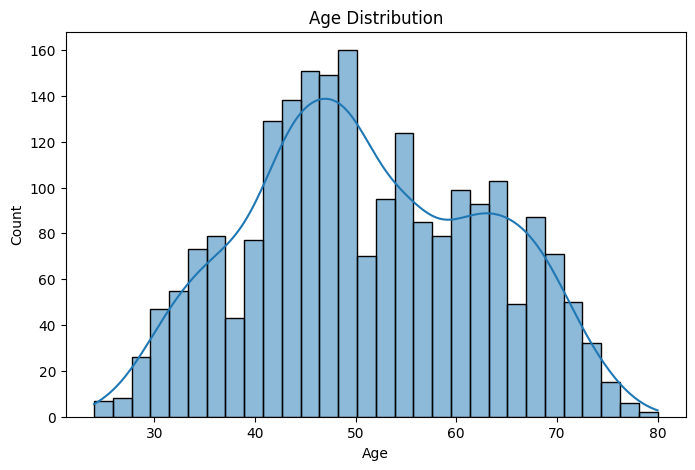

In [ ]:
#istplot for age distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

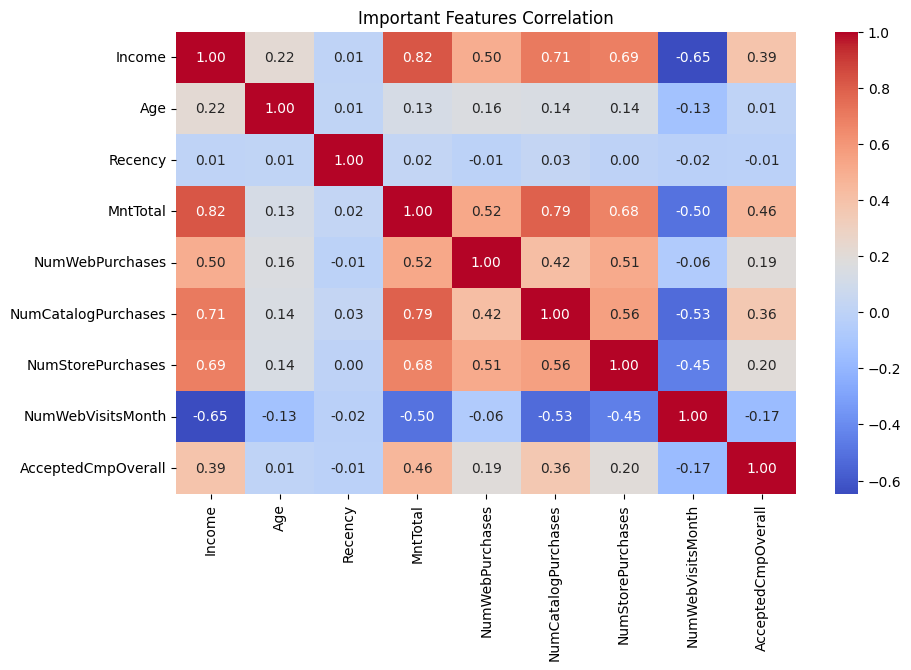

In [ ]:
important_cols = [
    'Income',
    'Age',
    'Recency',
    'MntTotal',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'AcceptedCmpOverall'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[important_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Important Features Correlation")
plt.show()

In [ ]:
#feature engineering
def get_marital_status(row):

    if row['marital_Divorced'] == 1:
        return 'Divorced'

    elif row['marital_Married'] == 1:
        return 'Married'

    elif row['marital_Single'] == 1:
        return 'Single'

    elif row['marital_Together'] == 1:
        return 'Together'

    elif row['marital_Widow'] == 1:
        return 'Widow'

    else:
        return 'Unknown'

df['Marital'] = df.apply(
    get_marital_status,
    axis=1
)

In [ ]:
df[['Marital']].head()

,Marital
0,Single
1,Single
2,Together
3,Together
4,Married


In [ ]:
df['Marital'].value_counts()

,count
Marital,
Married,854
Together,567
Single,475
Divorced,230
Widow,76


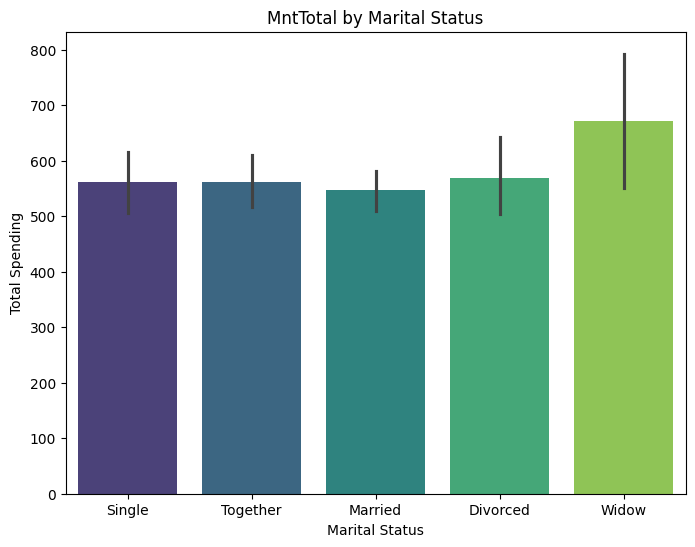

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='Marital',
    y='MntTotal',
    data=df,
    palette='viridis'
)

plt.title('MntTotal by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Spending')

plt.show()

In [ ]:
def get_relationship(row):

    if row['marital_Married'] == 1:
        return 1

    elif row['marital_Together'] == 1:
        return 1

    else:
        return 0

df['In_relationship'] = df.apply(
    get_relationship,
    axis=1
)

In [ ]:
df[['Marital','In_relationship']].head()

,Marital,In_relationship
0,Single,0
1,Single,0
2,Together,1
3,Together,1
4,Married,1


In [ ]:
df['In_relationship'].value_counts()

,count
In_relationship,
1,1421
0,781


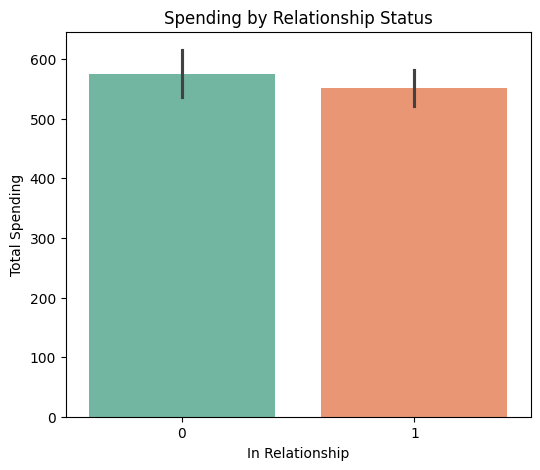

In [ ]:
#relationship vs spending chart
plt.figure(figsize=(6,5))

sns.barplot(
    x='In_relationship',
    y='MntTotal',
    data=df,
    palette='Set2'
)

plt.title('Spending by Relationship Status')
plt.xlabel('In Relationship')
plt.ylabel('Total Spending')

plt.show()

# K-Means Clustering
K-means clustering is an unsupervised machine learning algorithm used to cluster data based on similarity. K-means clustering usually works well in practice and scales well to the large datasets.

In this section:

1.Standardising data

2.Principal Component Analysis (PCA)

3.Elbow method

4.Silhouette score analysis

In [ ]:
df.shape

(2202, 39)

In [ ]:
#feature selection
features = [
    'Income',
    'MntTotal',
    'Recency',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'Age'
]

X = df[features]

In [ ]:
X.shape

(2202, 7)

In [ ]:
#standardising data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled[:5]

array([[ 0.3176686 ,  1.69381492,  0.31027604,  1.42438507,  2.63414766,
        -0.56114771,  1.01630446],
       [-0.2527859 , -0.94270124, -0.38086536, -1.1324417 , -0.58709992,
        -1.17850832,  1.27304279],
       [ 0.96943004,  0.30387437, -0.79555021,  1.42438507, -0.22918352,
         1.29093411,  0.33166892],
       [-1.20554261, -0.89549571, -0.79555021, -0.76718073, -0.94501632,
        -0.56114771, -1.29434049],
       [ 0.32516567, -0.26783702,  1.55433056,  0.32860217,  0.12873287,
         0.0562129 , -1.03760216]])

In [ ]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(X_pca.shape)

(2202, 2)


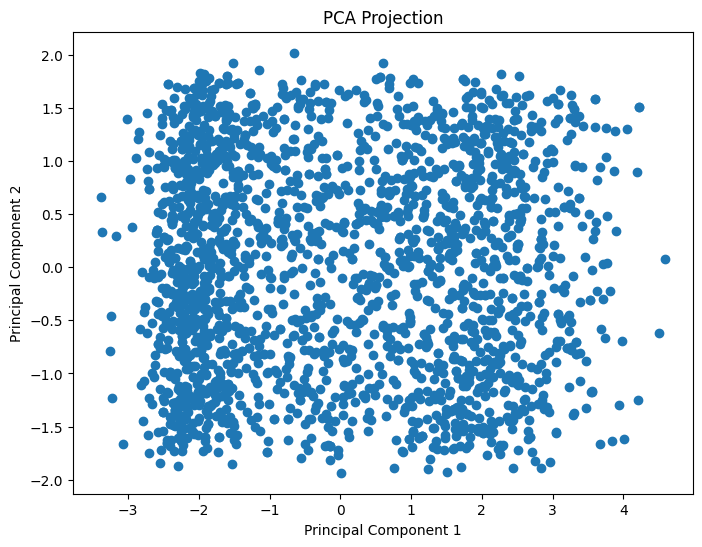

In [ ]:
#PCA scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()


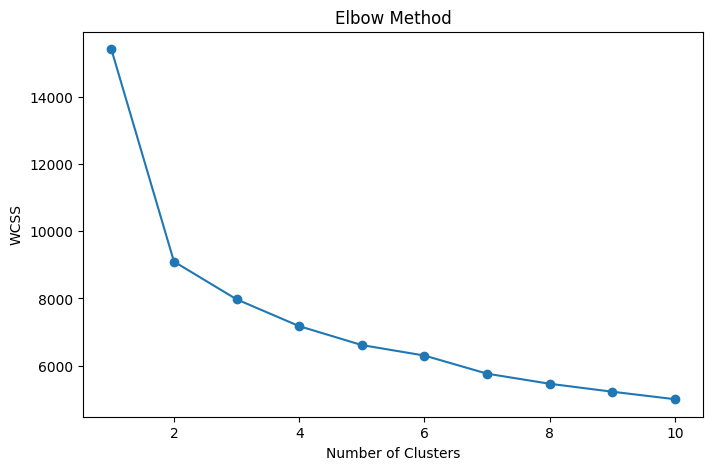

In [ ]:
#Elbow method
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.3620
K = 3 | Silhouette Score = 0.2558
K = 4 | Silhouette Score = 0.1963
K = 5 | Silhouette Score = 0.1944
K = 6 | Silhouette Score = 0.1876
K = 7 | Silhouette Score = 0.1932
K = 8 | Silhouette Score = 0.1918
K = 9 | Silhouette Score = 0.1925
K = 10 | Silhouette Score = 0.1920


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.3620
K = 3 | Silhouette Score = 0.2558
K = 4 | Silhouette Score = 0.1963
K = 5 | Silhouette Score = 0.1944
K = 6 | Silhouette Score = 0.1876
K = 7 | Silhouette Score = 0.1932
K = 8 | Silhouette Score = 0.1918
K = 9 | Silhouette Score = 0.1925
K = 10 | Silhouette Score = 0.1920


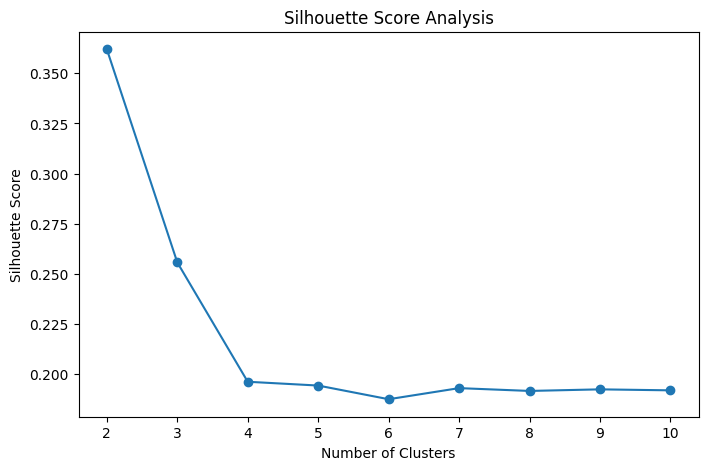

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.title("Silhouette Score Analysis")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,589
3,552
1,544
2,517


In [ ]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,In_relationship
Cluster,,,,,,,,,,,,,,,,,,,,,
0,59204.083192,0.224109,0.794567,41.862479,408.718166,31.590832,149.239389,41.069610,31.057725,60.079796,...,0.044143,0.076401,0.001698,0.494058,0.171477,0.256367,661.675722,601.595925,0.244482,0.657046
1,32549.005515,0.790441,0.398897,26.417279,35.957721,4.562500,20.060662,7.169118,4.472426,15.880515,...,0.025735,0.104779,0.066176,0.490809,0.161765,0.176471,72.222426,56.341912,0.108456,0.652574
2,37175.410058,0.740812,0.541586,76.081238,59.328820,6.593810,30.715667,9.208897,6.750484,20.367505,...,0.027079,0.106383,0.032882,0.508704,0.168279,0.183752,112.597679,92.230174,0.073501,0.649903
3,75652.559783,0.054348,0.275362,53.592391,689.407609,60.342391,447.777174,90.791667,63.706522,76.748188,...,0.039855,0.074275,0.000000,0.527174,0.155797,0.242754,1352.025362,1275.277174,0.750000,0.621377


In [ ]:
product_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

cluster_products = df.groupby('Cluster')[product_cols].mean()

cluster_products

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,408.718166,31.590832,149.239389,41.069610,31.057725,60.079796
1,35.957721,4.562500,20.060662,7.169118,4.472426,15.880515
2,59.328820,6.593810,30.715667,9.208897,6.750484,20.367505
3,689.407609,60.342391,447.777174,90.791667,63.706522,76.748188


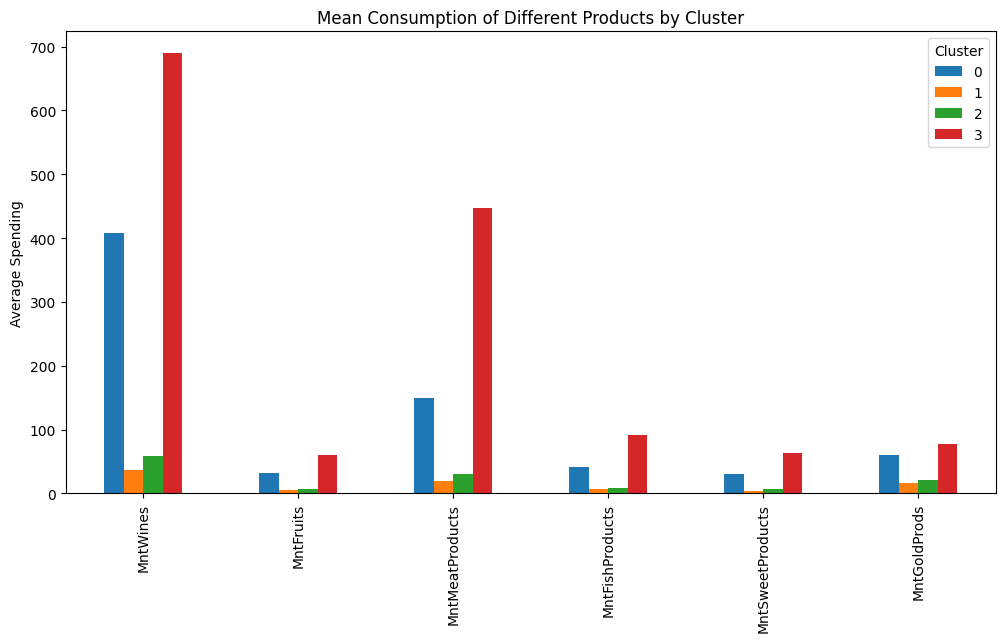

In [ ]:
cluster_products.T.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Mean Consumption of Different Products by Cluster")
plt.ylabel("Average Spending")
plt.show()

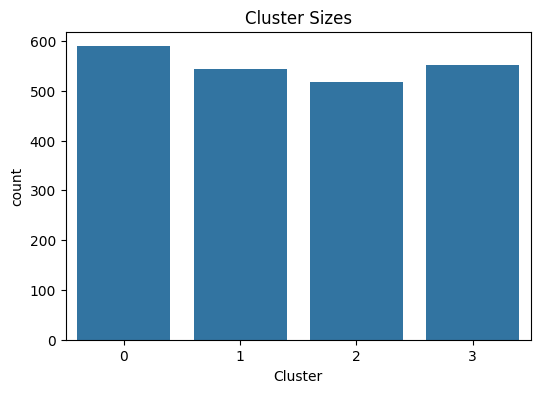

In [ ]:
#cluster sizes
plt.figure(figsize=(6,4))

sns.countplot(
    x='Cluster',
    data=df
)

plt.title("Cluster Sizes")

plt.show()

In [ ]:
#income cluster
income_cluster = df.groupby('Cluster')['Income'].mean()

income_cluster

,Income
Cluster,
0,59204.083192
1,32549.005515
2,37175.410058
3,75652.559783


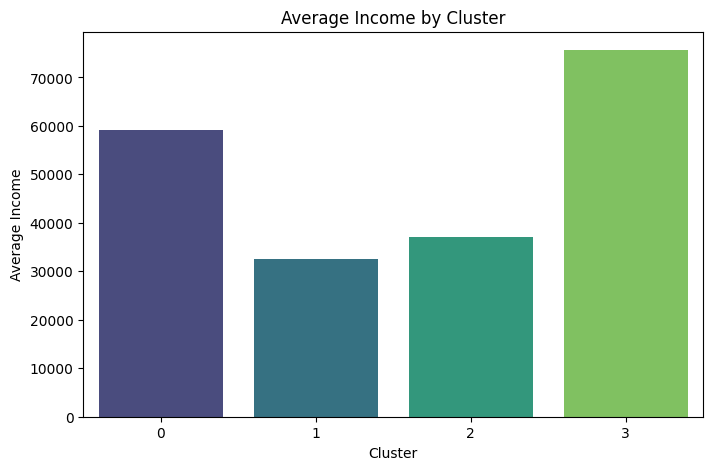

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=income_cluster.index,
    y=income_cluster.values,
    palette='viridis'
)

plt.title('Average Income by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Income')

plt.show()

In [ ]:
#In_relationship feature by cluster
relationship_cluster = df.groupby('Cluster')['In_relationship'].mean()

relationship_cluster

,In_relationship
Cluster,
0,0.657046
1,0.652574
2,0.649903
3,0.621377


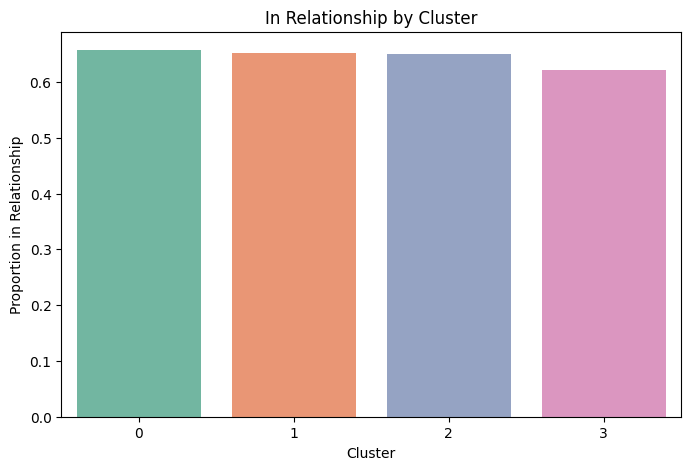

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=relationship_cluster.index,
    y=relationship_cluster.values,
    palette='Set2'
)

plt.title('In Relationship by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion in Relationship')

plt.show()

## Results

### Optimal Number of Clusters = 4

The Elbow Method and Silhouette Score Analysis were used to determine the optimal number of customer segments. Based on the analysis, 4 clusters were selected as they provided a meaningful separation of customers while maintaining good clustering performance.

### Cluster Characteristics

**Cluster 0 – High Value Customers in Relationship**

* Represents a significant portion of the customer base.
* Customers have relatively high income and spending patterns.
* Most customers are married or living together.

**Cluster 1 – Low Value Single Customers**

* Customers have lower income and lower overall spending.
* Majority of customers are single, divorced, or widowed.
* This segment shows lower purchasing activity.

**Cluster 2 – High Value Single Customers**

* Customers have high income and strong purchasing behavior.
* Most customers are single and demonstrate valuable buying patterns.
* This segment contributes significantly to overall sales.

**Cluster 3 – Low Value Customers in Relationship**

* Represents one of the largest customer groups.
* Customers have lower income and spending levels.
* Most customers are married or in a relationship.

The clustering analysis successfully identified distinct customer groups based on income, spending behavior, and relationship status, providing valuable business insights.


## Recommendations

Different customer segments require different marketing approaches to maximize engagement and revenue.

### Cluster 0 – High Value Customers in Relationship

* Promote premium products and exclusive offers.
* Use family-oriented marketing campaigns.
* Introduce loyalty and VIP reward programs.

### Cluster 1 – Low Value Single Customers

* Offer discounts, coupons, and promotional campaigns.
* Encourage repeat purchases through loyalty programs.
* Focus on affordable product recommendations.

### Cluster 2 – High Value Single Customers

* Promote premium lifestyle products and exclusive deals.
* Use marketing campaigns focused on individual experiences, travel, and social activities.
* Provide personalized recommendations based on purchasing history.

### Cluster 3 – Low Value Customers in Relationship

* Introduce family bundles and value-based offers.
* Promote seasonal discounts and combo packages.
* Encourage higher spending through targeted promotional campaigns.

Implementing these strategies can improve customer retention, increase sales, and help the business allocate marketing resources more effectively.
